#📌 Extracción

In [1]:
import requests
import json

url = 'https://raw.githubusercontent.com/Coobaltoo13/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json' # Replace with your raw GitHub URL
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    json_data = response.json()
    print("JSON data loaded successfully as a Python dictionary.")
    # You can now work with json_data as a dictionary
    # print(json_data)
else:
    print(f"Failed to fetch file. Status code: {response.status_code}")

JSON data loaded successfully as a Python dictionary.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#🔧 Transformación

In [10]:
import pandas as pd

df = pd.DataFrame(json_data)
print("json_data successfully converted to a pandas DataFrame named 'df'.")
print(df.head())

json_data successfully converted to a pandas DataFrame named 'df'.
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', 'OnlineSecurity': '..

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [7]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [13]:
from pandas import json_normalize
import pandas as pd

# Re-initialize df from json_data to ensure original nested columns are present
df = pd.DataFrame(json_data)

# Normalize 'customer' column
customer_df = json_normalize(df['customer'])

# Normalize 'phone' column
phone_df = json_normalize(df['phone'])

# Normalize 'internet' column
internet_df = json_normalize(df['internet'])

# Normalize 'account' column
account_df = json_normalize(df['account'])

# Concatenate the new dataframes with the original df and drop the nested columns
df = pd.concat([df[['customerID', 'Churn']], customer_df, phone_df, internet_df, account_df], axis=1)

# Convert 'Charges.Total' to numeric, coercing errors
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

# Convert 'SeniorCitizen' to boolean
df['SeniorCitizen'] = df['SeniorCitizen'].astype(bool)

print("Dictionary columns expanded and data types adjusted.")
print(df.head())
print(df.info())

Dictionary columns expanded and data types adjusted.
   customerID Churn  gender  SeniorCitizen Partner Dependents  tenure  \
0  0002-ORFBO    No  Female          False     Yes        Yes       9   
1  0003-MKNFE    No    Male          False      No         No       9   
2  0004-TLHLJ   Yes    Male          False      No         No       4   
3  0011-IGKFF   Yes    Male           True     Yes         No      13   
4  0013-EXCHZ   Yes  Female           True     Yes         No       3   

  PhoneService MultipleLines InternetService  ... OnlineBackup  \
0          Yes            No             DSL  ...          Yes   
1          Yes           Yes             DSL  ...           No   
2          Yes            No     Fiber optic  ...           No   
3          Yes            No     Fiber optic  ...          Yes   
4          Yes            No     Fiber optic  ...           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No         Yes   

In [14]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,False,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,False,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,False,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,True,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,True,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [21]:
df.Churn.value_counts()

,count
Churn,
No,5174
Yes,1869
,224


Top 10 Feature Importances:
                            Feature  Importance
0                            tenure    0.497738
12          Contract_month-to-month    0.137538
2                 OnlineSecurity_no    0.064683
1       InternetService_fiber optic    0.059656
13                Contract_two year    0.058322
8                    TechSupport_no    0.058102
14   PaymentMethod_electronic check    0.045692
4                   OnlineBackup_no    0.028208
6               DeviceProtection_no    0.026351
10  StreamingTV_no internet service    0.005333


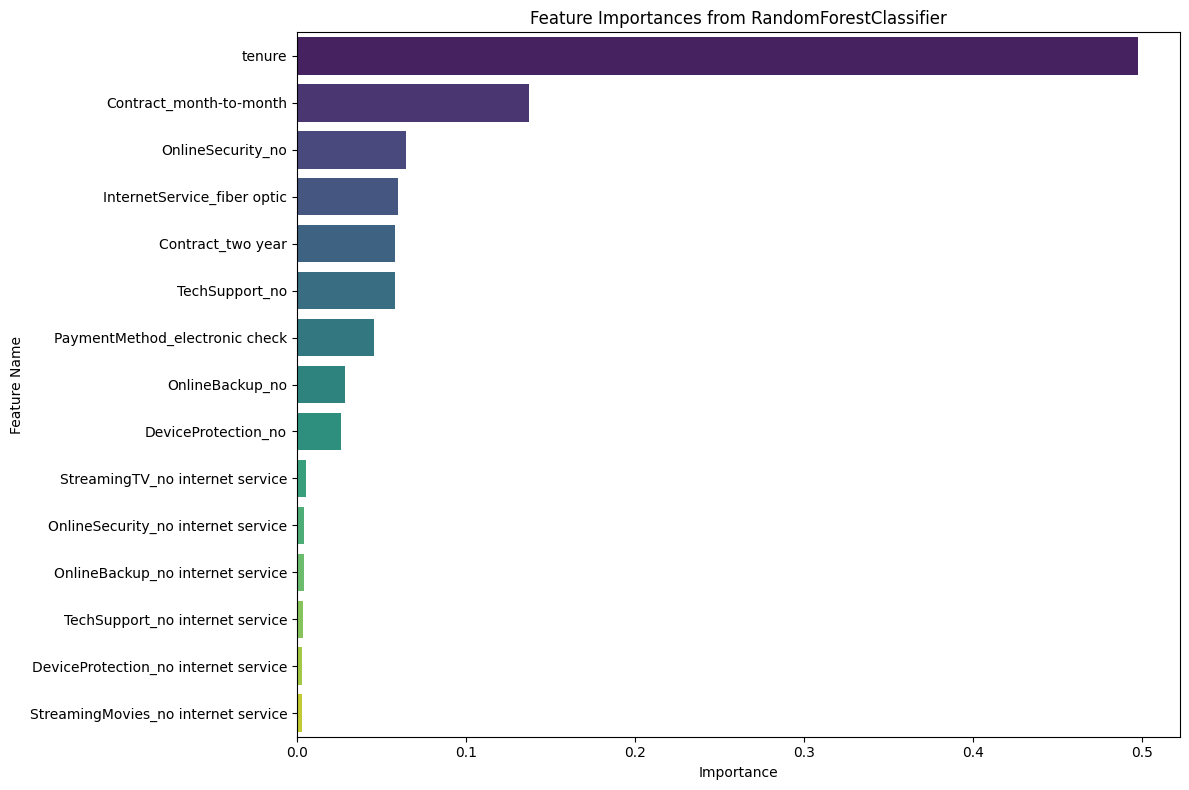

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Create a DataFrame to store feature names and their importances
feature_importance_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': feature_importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the top N most important features
print("Top 10 Feature Importances:")
print(feature_importance_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importances from RandomForestClassifier')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [33]:
print("\n--- Descriptive Statistics for Numerical Features ---")
# Describe numerical columns
print(df.describe())

print("\n--- Descriptive Statistics for Categorical Features ---")
# Describe categorical (object) columns
print(df.describe(include='object'))

print("\n--- Value Counts for Boolean/Binary Features ---")
# For boolean or binary-like features, value_counts provides more insight
print("\nSeniorCitizen Value Counts:")
print(df['SeniorCitizen'].value_counts())

# You can also look at specific categorical columns in more detail
print("\nGender Value Counts:")
print(df['gender'].value_counts())

print("\nContract Type Value Counts:")
print(df['Contract'].value_counts())



--- Descriptive Statistics for Numerical Features ---
            tenure  Charges.Monthly  Charges.Total
count  7043.000000      7043.000000    7043.000000
mean     32.371149        64.761692    2283.296277
std      24.559481        30.090047    2265.000260
min       0.000000        18.250000      18.800000
25%       9.000000        35.500000     402.225000
50%      29.000000        70.350000    1400.550000
75%      55.000000        89.850000    3786.600000
max      72.000000       118.750000    8684.800000

--- Descriptive Statistics for Categorical Features ---
        customerID Churn gender Partner Dependents PhoneService MultipleLines  \
count         7043  7043   7043    7043       7043         7043          7043   
unique        7043     2      2       2          2            2             3   
top     9995-HOTOH    No   male      no         no          yes            no   
freq             1  5174   3555    3641       4933         6361          3390   

       InternetService 

Shape of X_train: (5634, 15)
Shape of X_test: (1409, 15)
Shape of y_train: (5634,)
Shape of y_test: (1409,)
RandomForestClassifier model trained successfully with balanced class weights.

--- Model Evaluation ---
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.79      0.82      1035
           1       0.52      0.62      0.56       374

    accuracy                           0.74      1409
   macro avg       0.68      0.70      0.69      1409
weighted avg       0.76      0.74      0.75      1409

ROC AUC Score: 0.7821

Confusion Matrix:


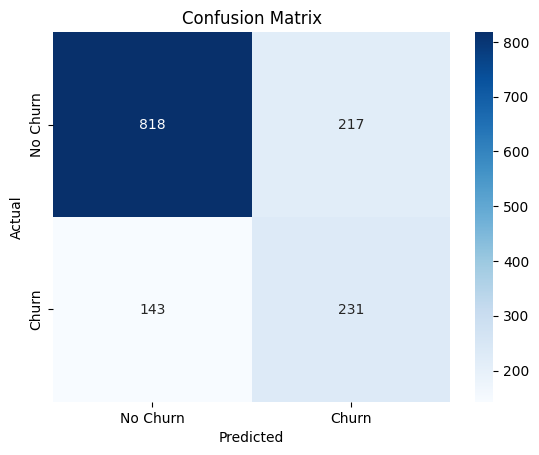

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Split the data into training and testing sets
# Using X_selected (features after selection) and y (encoded Churn)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Initialize a RandomForestClassifier with class_weight='balanced'
# This helps address imbalanced datasets by automatically adjusting weights
# inversely proportional to class frequencies.
model = RandomForestClassifier(class_weight='balanced', random_state=42)

# Train the model
model.fit(X_train, y_train)

print("RandomForestClassifier model trained successfully with balanced class weights.")

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class (churn)

# Evaluate the model
print("\n--- Model Evaluation ---")
print("Classification Report:")
print(classification_report(y_test, y_pred))

print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Confusion Matrix for a clearer view
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

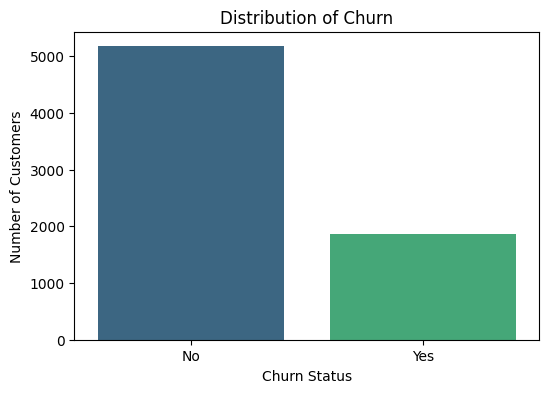

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis', hue='Churn', legend=False)
plt.title('Distribution of Churn')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

In [20]:
df.customerID.value_counts()

,count
customerID,
9995-HOTOH,1
0002-ORFBO,1
0003-MKNFE,1
9970-QBCDA,1
9968-FFVVH,1
...,...
0014-BMAQU,1
0013-SMEOE,1
0013-MHZWF,1


In [22]:
import numpy as np

# Fill missing values in 'Charges.Total' with the mean
df['Charges.Total'] = df['Charges.Total'].replace(' ', np.nan) # Replace spaces with NaN first if any
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
df['Charges.Total'] = df['Charges.Total'].fillna(df['Charges.Total'].mean())
print("Missing values in 'Charges.Total' filled with the mean.")

Missing values in 'Charges.Total' filled with the mean.


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.compose import ColumnTransformer

# Separate features (X) and target (y)
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

# Encode target variable 'Churn' (Yes/No to 1/0)
le = LabelEncoder()
y = le.fit_transform(y)
print(f"Target variable 'Churn' encoded: {le.classes_} -> {le.transform(le.classes_)}")

# Identify categorical and numerical columns in X
categorical_features = X.select_dtypes(include=['object', 'bool']).columns
numerical_features = X.select_dtypes(include=[np.number]).columns

# Create a ColumnTransformer for one-hot encoding categorical features
# and passing through numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Apply preprocessing to X
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
# This part can be tricky, especially with handle_unknown='ignore'
# A more robust way would be to get feature names after fit

# For simplicity, let's just use the transformed array for SelectKBest directly
# If feature names are needed for analysis later, a pipeline would be better

print("Categorical features encoded and numerical features passed through.")
print(f"Shape of X_processed: {X_processed.shape}")

Target variable 'Churn' encoded: ['No' 'Yes'] -> [0 1]
Categorical features encoded and numerical features passed through.
Shape of X_processed: (7043, 46)


In [30]:
# Perform feature selection using SelectKBest
k_best_selector = SelectKBest(f_classif, k=15) # Select top 15 features
X_selected = k_best_selector.fit_transform(X_processed, y)

# Get the indices of the selected features
selected_feature_indices = k_best_selector.get_support(indices=True)

# Get the feature names after preprocessing, before selection
# This requires knowing the order of columns from ColumnTransformer

# Get original numerical feature names
original_numerical_features = list(numerical_features)

# Get one-hot encoded feature names
one_hot_encoder = preprocessor.named_transformers_['cat']
encoded_feature_names = one_hot_encoder.get_feature_names_out(categorical_features)

all_processed_feature_names = original_numerical_features + list(encoded_feature_names)

# Get the names of the selected features
selected_feature_names = [all_processed_feature_names[i] for i in selected_feature_indices]

print(f"Selected {len(selected_feature_names)} features:")
for feature_name in selected_feature_names:
    print(f"- {feature_name}")

print(f"Shape of X_selected (features after selection): {X_selected.shape}")

Selected 15 features:
- tenure
- InternetService_fiber optic
- OnlineSecurity_no
- OnlineSecurity_no internet service
- OnlineBackup_no
- OnlineBackup_no internet service
- DeviceProtection_no
- DeviceProtection_no internet service
- TechSupport_no
- TechSupport_no internet service
- StreamingTV_no internet service
- StreamingMovies_no internet service
- Contract_month-to-month
- Contract_two year
- PaymentMethod_electronic check
Shape of X_selected (features after selection): (7043, 15)


In [24]:
print("Consistency check for 'gender' column:")
print(df.gender.value_counts())
print("\nConsistency check for 'Churn' column:")
print(df.Churn.value_counts())

Consistency check for 'gender' column:
gender
male      3675
female    3592
Name: count, dtype: int64

Consistency check for 'Churn' column:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64


In [25]:
import numpy as np

# Eliminate duplicate rows
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - df.shape[0]
print(f"Removed {duplicates_removed} duplicate rows.")

# Handle inconsistencies in 'Churn' column (empty strings)
print(f"\nInitial Churn value counts:\n{df['Churn'].value_counts(dropna=False)}")

# First, strip any leading/trailing whitespace from the Churn column
df['Churn'] = df['Churn'].str.strip()

# Now replace true empty strings ('') with NaN
df['Churn'] = df['Churn'].replace('', np.nan)

churn_nan_count = df['Churn'].isnull().sum()
df.dropna(subset=['Churn'], inplace=True)
print(f"Removed {churn_nan_count} rows with empty 'Churn' values.")
print(f"Updated Churn value counts:\n{df['Churn'].value_counts(dropna=False)}") # Use dropna=False to confirm no NaNs are left

# Standardize string values (lowercase and strip whitespace) for consistency
# Exclude 'customerID' as it's an identifier and 'Churn' as it's already handled
for col in df.select_dtypes(include='object').columns:
    if col not in ['customerID', 'Churn']:
        df[col] = df[col].str.lower().str.strip()
print("\nObject columns standardized to lowercase and whitespace stripped (excluding customerID and Churn).")
print(f"New DataFrame shape after cleaning: {df.shape}")

Removed 0 duplicate rows.

Initial Churn value counts:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64
Removed 224 rows with empty 'Churn' values.
Updated Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Object columns standardized to lowercase and whitespace stripped (excluding customerID and Churn).
New DataFrame shape after cleaning: (7043, 21)


#📊 Carga y análisis

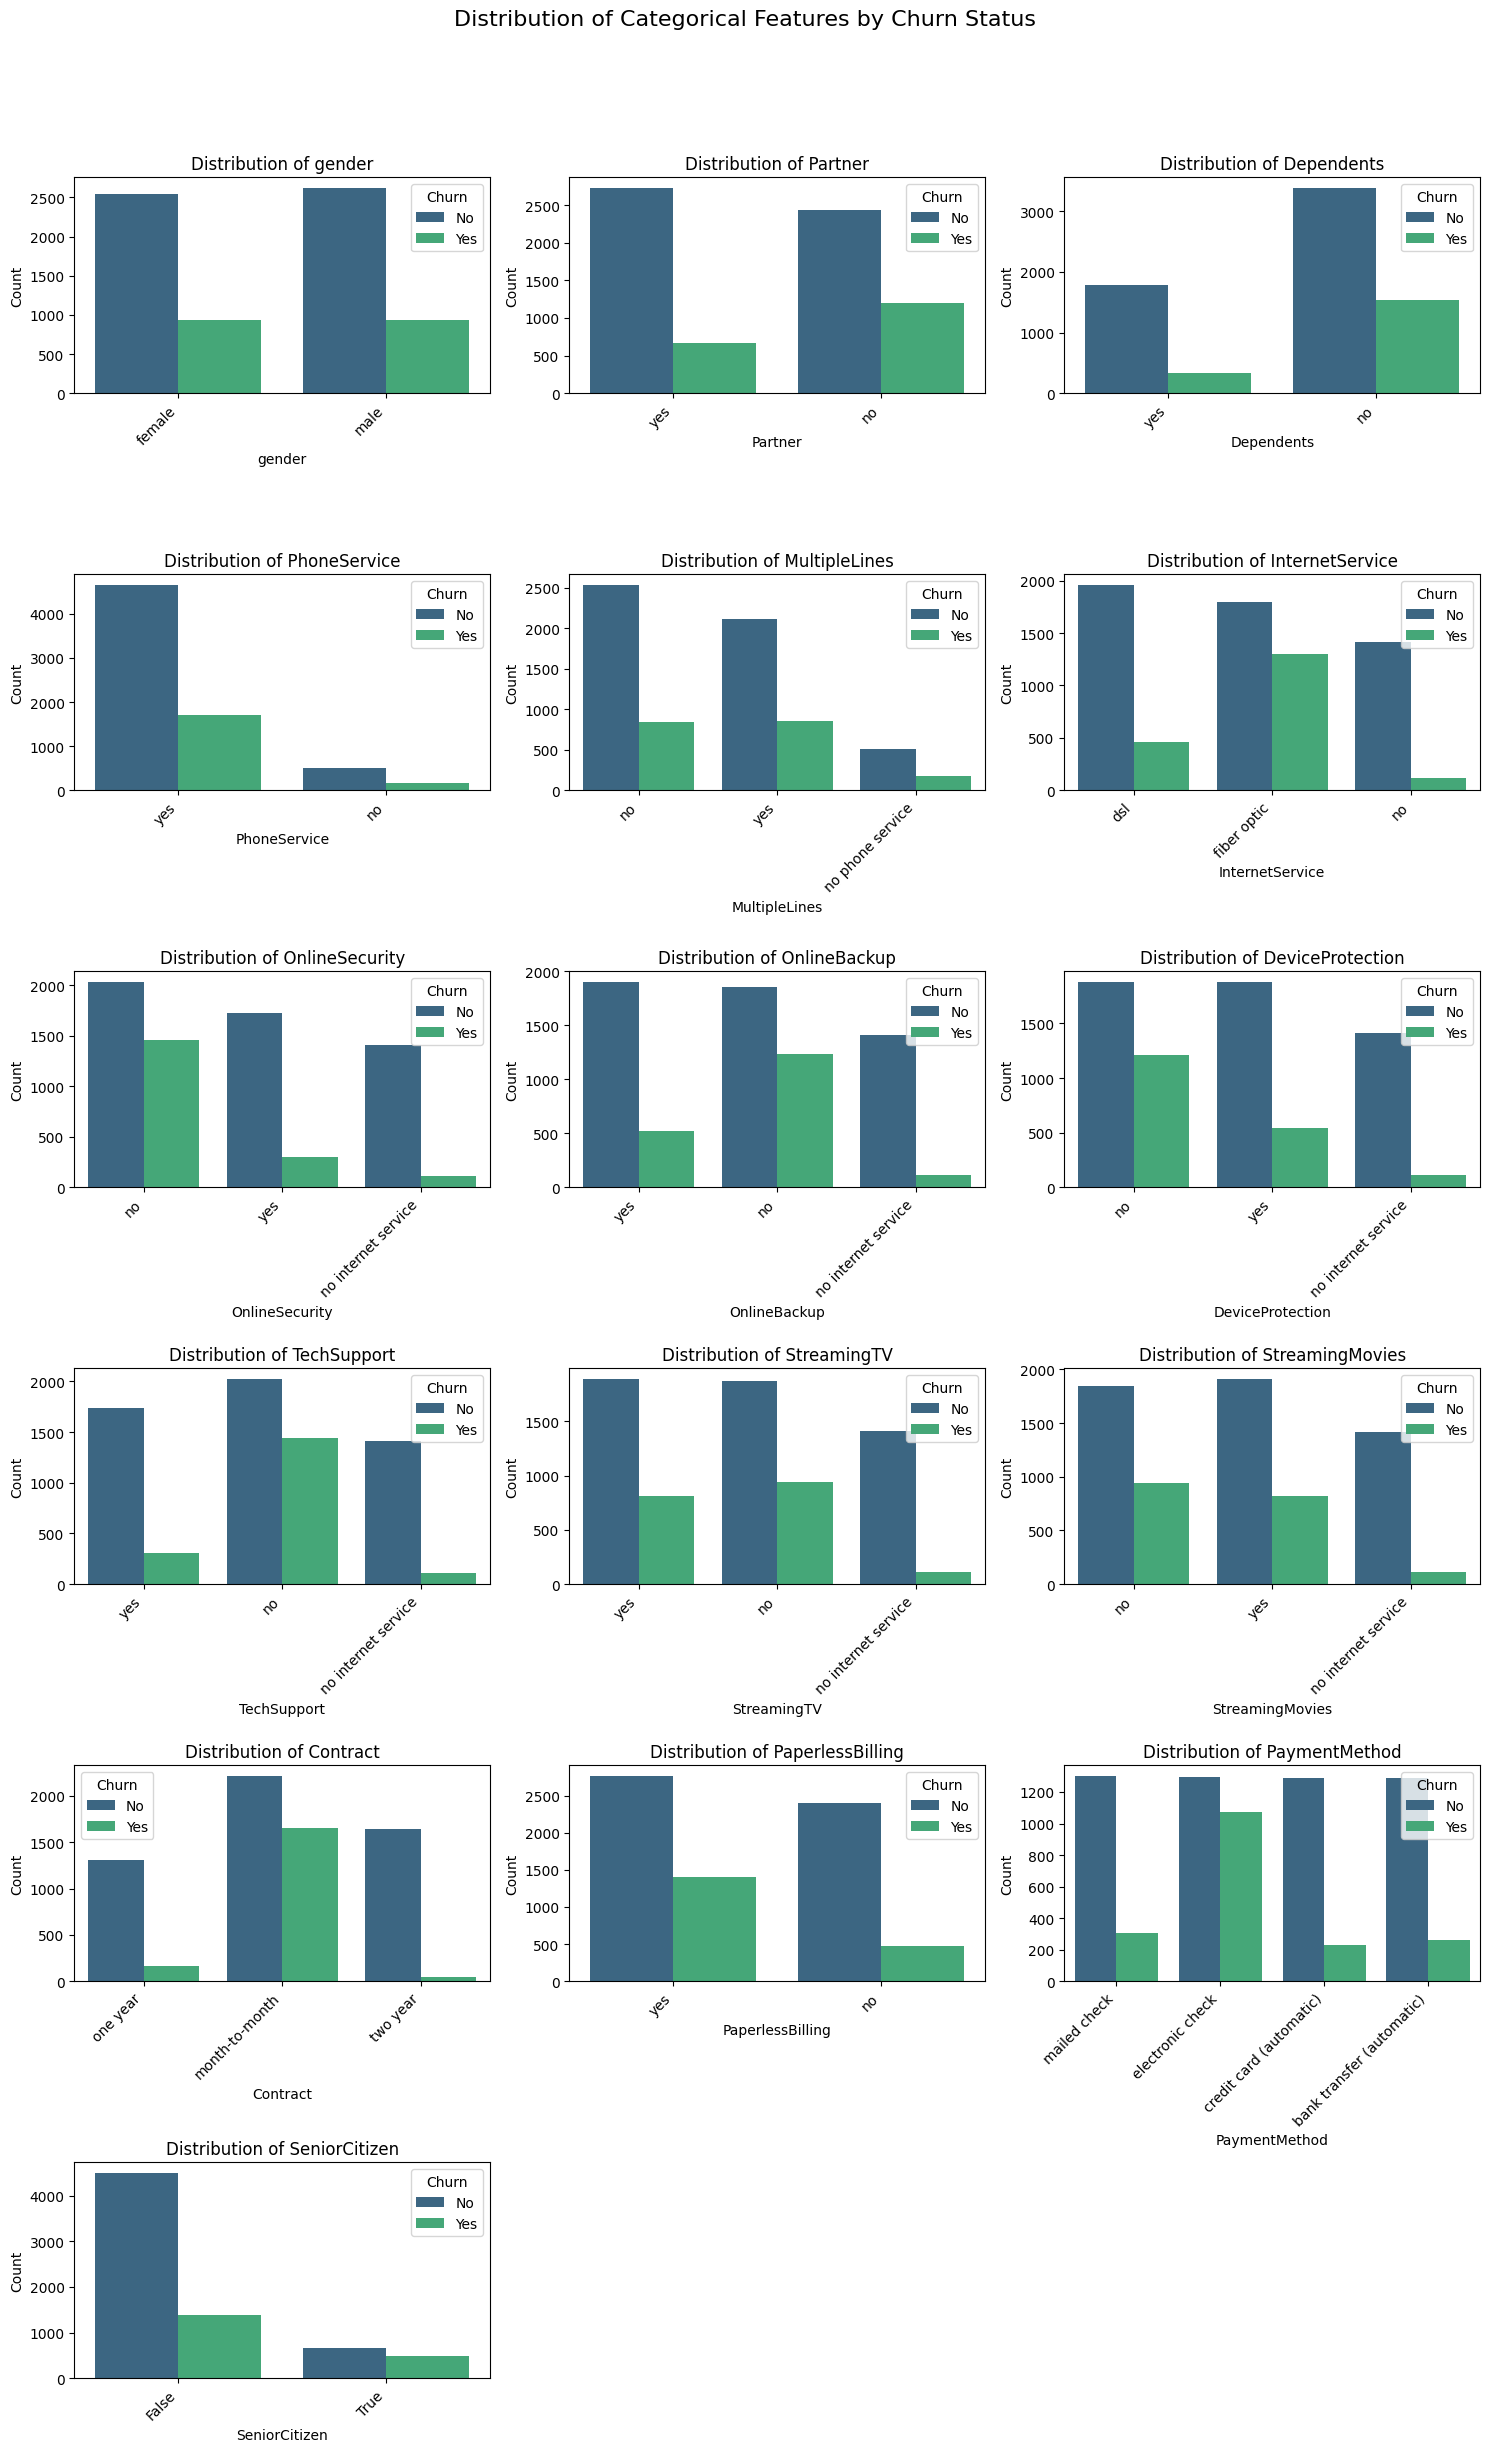

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features = df.select_dtypes(include='object').columns.tolist()
categorical_features.remove('customerID') # Remove customerID as it's a unique identifier
categorical_features.remove('Churn')      # Remove Churn as it's the target variable

# Adding SeniorCitizen as a categorical for visualization purposes
categorical_features.append('SeniorCitizen')

# Determine the number of rows and columns for the subplot grid
n_features = len(categorical_features)
n_cols = 3  # You can adjust this number
n_rows = (n_features + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4))
plt.suptitle('Distribution of Categorical Features by Churn Status', y=1.02, fontsize=16)

for i, feature in enumerate(categorical_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(x=feature, hue='Churn', data=df, palette='viridis', legend=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

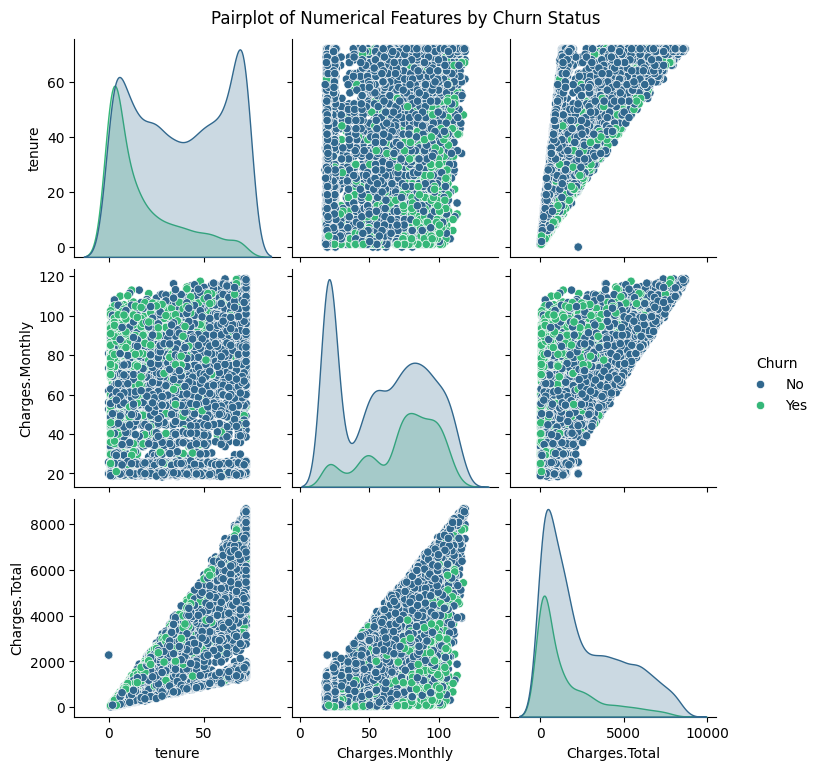

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns and the 'Churn' column for the pairplot
numerical_cols = ['tenure', 'Charges.Monthly', 'Charges.Total']
pairplot_df = df[numerical_cols + ['Churn']]

# Create the pairplot with 'Churn' as the hue
sns.pairplot(pairplot_df, hue='Churn', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features by Churn Status', y=1.02) # Adjust suptitle position
plt.show()

#📄Informe final